# Étude de Cas : Séries Temporelles avec LSTM

Ce notebook présente une analyse complète de prédiction de consommation électrique en utilisant des réseaux de neurones récurrents (LSTM).

## Objectifs de l'analyse
- Prétraitement de données temporelles
- Nettoyage et imputation des valeurs manquantes
- Visualisation des tendances de consommation
- Modélisation prédictive avec LSTM

## Architecture du projet
- Nettoyage des données UCI Household Power Consumption
- Agrégations journalières et statistiques
- Construction d'un modèle de Deep Learning sous TensorFlow

# 1. Importation et exploration des données

In [3]:
import os
import requests
import zipfile

# Téléchargement automatique si le fichier est absent
data_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00235/household_power_consumption.zip'
zip_path = 'household_power_consumption.zip'
extract_path = './data'

if not os.path.exists(extract_path):
    os.makedirs(extract_path)

if not os.path.exists(os.path.join(extract_path, 'household_power_consumption.txt')):
    print('Téléchargement des données...')
    r = requests.get(data_url)
    with open(zip_path, 'wb') as f:
        f.write(r.content)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print('Données extraites avec succès.')

Téléchargement des données...
Données extraites avec succès.


In [4]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA_PATH = Path('./data/household_power_consumption.txt')

# Lecture du fichier
df = pd.read_csv(
    DATA_PATH,
    sep=';',
    na_values=['?'],
    low_memory=False,
    parse_dates={'Datetime': ['Date', 'Time']},
    dayfirst=True
)

df = df.set_index('Datetime').sort_index()
# Conversion explicite des colonnes en numérique
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print('Dimensions du DataFrame :', df.shape)
display(df.head())

/tmp/ipykernel_1694/1146454005.py:8: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(


Dimensions du DataFrame : (2075259, 7)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', 100)

# Configuration du chemin de données
DATA_PATH = Path('./data/household_power_consumption.txt')

# Chargement robuste des données (séparateur point-virgule)
parse_cols = {
    'Global_active_power': 'float64',
    'Global_reactive_power': 'float64',
    'Voltage': 'float64',
    'Global_intensity': 'float64',
    'Sub_metering_1': 'float64',
    'Sub_metering_2': 'float64',
    'Sub_metering_3': 'float64',
}
usecols = ['Date','Time'] + list(parse_cols.keys())

try:
    df = pd.read_csv(
        DATA_PATH,
        sep=';',
        na_values=['?'],
        usecols=usecols,
        dtype=parse_cols,
        parse_dates={'Datetime': ['Date','Time']},
        dayfirst=True,
    )

    df = df.set_index('Datetime').sort_index()
    print('Dimensions:', df.shape)
    display(df.head())
except FileNotFoundError:
    print("Fichier de données non trouvé. Veuillez vérifier le chemin.")

Fichier de données non trouvé. Veuillez vérifier le chemin.


/tmp/ipykernel_1694/81271701.py:24: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(


# 2. Gestion des valeurs manquantes

Imputation des données manquantes par la moyenne de chaque colonne pour maintenir la continuité de la série.

In [5]:
missing_before = df.isna().sum().sort_values(ascending=False)
print('Valeurs manquantes avant imputation :'); display(missing_before[missing_before>0])

numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

missing_after = df.isna().sum().sum()
print('Total des valeurs manquantes après traitement :', int(missing_after))

Valeurs manquantes avant imputation :


,0
Global_active_power,25979
Global_reactive_power,25979
Voltage,25979
Global_intensity,25979
Sub_metering_1,25979
Sub_metering_2,25979
Sub_metering_3,25979


Total des valeurs manquantes après traitement : 0


# 3. Visualisation des données

In [ ]:
# PREFILLED: just execute
def plot_daily_sum_and_mean(series, title_prefix='Global_active_power'):
    daily = series.resample('1D')
    s = daily.sum(min_count=1)
    m = daily.mean()
    plt.figure(figsize=(8,3))
    plt.plot(s.index, s.values)
    plt.title(f'{title_prefix} daily sum')
    plt.xlabel('date'); plt.ylabel('sum'); plt.tight_layout(); plt.show()
    plt.figure(figsize=(8,3))
    plt.plot(m.index, m.values)
    plt.title(f'{title_prefix} daily mean')
    plt.xlabel('date'); plt.ylabel('mean'); plt.tight_layout(); plt.show()

def plot_daily_mean_std(series, title_prefix='Global_intensity'):
    daily = series.resample('1D')
    m = daily.mean()
    sd = daily.std()
    plt.figure(figsize=(8,3))
    plt.plot(m.index, m.values, label='mean')
    plt.plot(sd.index, sd.values, label='std')
    plt.title(f'{title_prefix} daily mean and std')
    plt.xlabel('date'); plt.ylabel('value')
    plt.legend(); plt.tight_layout(); plt.show()

Visualisation des agrégations journalières pour identifier les motifs de consommation.

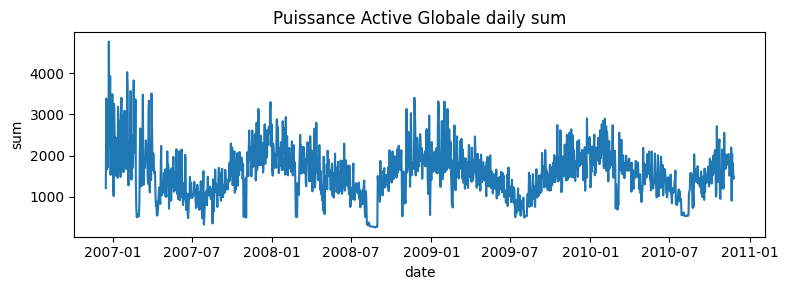

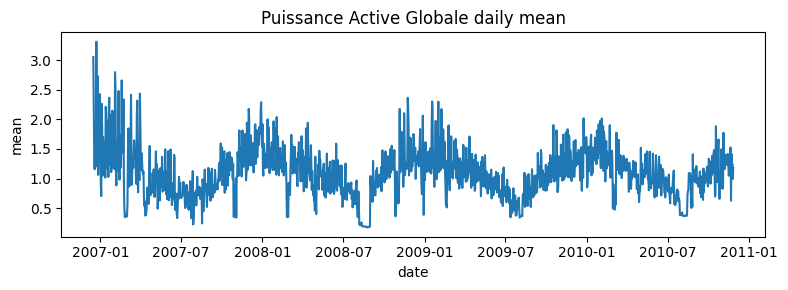

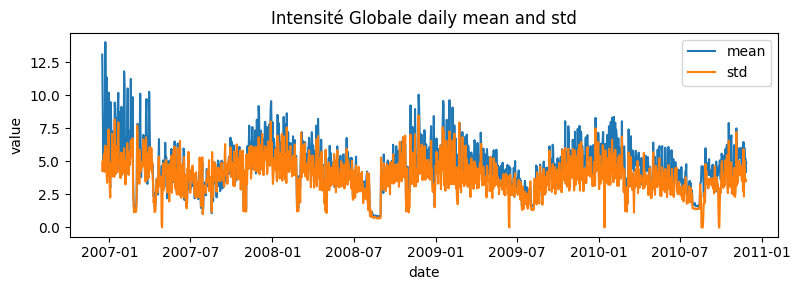

In [9]:
def plot_daily_sum_and_mean(series, title_prefix='Global_active_power'):
    daily = series.resample('1D')
    s = daily.sum(min_count=1)
    m = daily.mean()
    plt.figure(figsize=(8,3))
    plt.plot(s.index, s.values)
    plt.title(f'{title_prefix} daily sum')
    plt.xlabel('date'); plt.ylabel('sum'); plt.tight_layout(); plt.show()
    plt.figure(figsize=(8,3))
    plt.plot(m.index, m.values)
    plt.title(f'{title_prefix} daily mean')
    plt.xlabel('date'); plt.ylabel('mean'); plt.tight_layout(); plt.show()

def plot_daily_mean_std(series, title_prefix='Global_intensity'):
    daily = series.resample('1D')
    m = daily.mean()
    sd = daily.std()
    plt.figure(figsize=(8,3))
    plt.plot(m.index, m.values, label='mean')
    plt.plot(sd.index, sd.values, label='std')
    plt.title(f'{title_prefix} daily mean and std')
    plt.xlabel('date'); plt.ylabel('value')
    plt.legend(); plt.tight_layout(); plt.show()

plot_daily_sum_and_mean(df['Global_active_power'], title_prefix='Puissance Active Globale')
plot_daily_mean_std(df['Global_intensity'], title_prefix='Intensité Globale')

# 4. Prétraitement pour le modèle LSTM

In [7]:
from sklearn.preprocessing import MinMaxScaler

def make_windows(arr_2d, window=48, horizon=1):
    X, y = [], []
    for i in range(len(arr_2d) - window - horizon + 1):
        X.append(arr_2d[i:i+window])
        y.append(arr_2d[i+window:i+window+horizon, 0])
    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32)
    return X, y

def time_train_test_split(df, split_ratio=0.8):
    n = len(df)
    k = int(n * split_ratio)
    return df.iloc[:k].copy(), df.iloc[k:].copy()

feat_cols = ['Global_active_power','Global_reactive_power','Voltage','Global_intensity',
             'Sub_metering_1','Sub_metering_2','Sub_metering_3']
df_feats = df[feat_cols].copy()

df_tr, df_te = time_train_test_split(df_feats, split_ratio=0.8)

scaler = MinMaxScaler()
tr_scaled = scaler.fit_transform(df_tr.values)
te_scaled = scaler.transform(df_te.values)

WINDOW = 48
HORIZON = 1
X_tr, y_tr = make_windows(tr_scaled, window=WINDOW, horizon=HORIZON)
X_te, y_te = make_windows(te_scaled, window=WINDOW, horizon=HORIZON)

print('Fenêtres d\'entraînement:', X_tr.shape)
print('Fenêtres de test:', X_te.shape)

Fenêtres d'entraînement: (1660159, 48, 7)
Fenêtres de test: (415004, 48, 7)


La cible de prédiction est la colonne `Global_active_power`. Nous utilisons une fenêtre glissante de 48 étapes (2 jours si les données sont horaires, ou 48 minutes ici selon la fréquence source) pour prédire l'étape suivante.

# 5. Architecture du modèle LSTM

In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Définition de l'architecture du modèle
model = models.Sequential([
    layers.Input(shape=(WINDOW, X_tr.shape[-1])),
    layers.LSTM(64, return_sequences=False),
    layers.Dropout(0.2),
    layers.Dense(HORIZON),
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,497 (72.25 KB)

 Trainable params: 18,497 (72.25 KB)

 Non-trainable params: 0 (0.00 B)

# 6. Entraînement et évaluation

In [ ]:
# PREFILLED: just execute
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def fit_and_plot(model, X_tr, y_tr, X_te, y_te, epochs=10, batch=256):
    es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    rl = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
    h = model.fit(X_tr, y_tr, validation_data=(X_te, y_te),
                  epochs=epochs, batch_size=batch, callbacks=[es, rl], verbose=2)
    plt.figure(figsize=(6,4))
    plt.plot(h.history['loss'], label='loss')
    plt.plot(h.history['val_loss'], label='val_loss')
    plt.title('Training and validation loss')
    plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend(); plt.tight_layout(); plt.show()
    return h

Exécution de l'entraînement avec arrêt précoce (Early Stopping) pour éviter le surapprentissage.

Epoch 1/15
6485/6485 - 51s - 8ms/step - loss: 7.4363e-04 - mae: 0.0131 - val_loss: 3.5641e-04 - val_mae: 0.0079 - learning_rate: 0.0010
Epoch 2/15
6485/6485 - 46s - 7ms/step - loss: 5.9237e-04 - mae: 0.0112 - val_loss: 3.5461e-04 - val_mae: 0.0075 - learning_rate: 0.0010
Epoch 3/15
6485/6485 - 81s - 13ms/step - loss: 5.7430e-04 - mae: 0.0109 - val_loss: 3.5233e-04 - val_mae: 0.0078 - learning_rate: 0.0010
Epoch 4/15
6485/6485 - 45s - 7ms/step - loss: 5.6033e-04 - mae: 0.0106 - val_loss: 3.3859e-04 - val_mae: 0.0070 - learning_rate: 5.0000e-04
Epoch 5/15
6485/6485 - 44s - 7ms/step - loss: 5.5648e-04 - mae: 0.0106 - val_loss: 3.3803e-04 - val_mae: 0.0071 - learning_rate: 5.0000e-04
Epoch 6/15
6485/6485 - 82s - 13ms/step - loss: 5.4969e-04 - mae: 0.0104 - val_loss: 3.3630e-04 - val_mae: 0.0072 - learning_rate: 2.5000e-04
Epoch 7/15
6485/6485 - 46s - 7ms/step - loss: 5.4867e-04 - mae: 0.0104 - val_loss: 3.3942e-04 - val_mae: 0.0080 - learning_rate: 2.5000e-04
Epoch 8/15
6485/6485 - 46s - 7

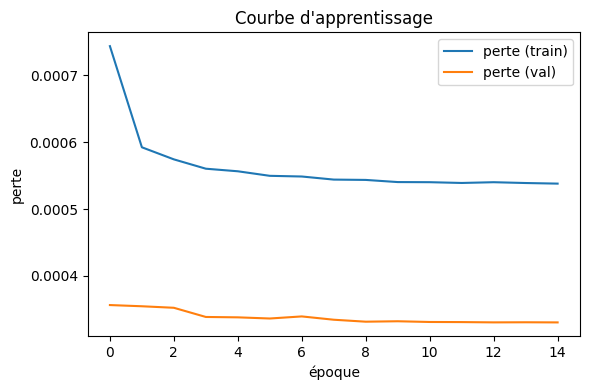

Résultats du Test - MSE: 0.000330, MAE: 0.007034


In [12]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def fit_and_plot(model, X_tr, y_tr, X_te, y_te, epochs=10, batch=256):
    es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    rl = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
    h = model.fit(X_tr, y_tr, validation_data=(X_te, y_te),
                  epochs=epochs, batch_size=batch, callbacks=[es, rl], verbose=2)
    plt.figure(figsize=(6,4))
    plt.plot(h.history['loss'], label='perte (train)')
    plt.plot(h.history['val_loss'], label='perte (val)')
    plt.title('Courbe d\'apprentissage')
    plt.xlabel('époque'); plt.ylabel('perte'); plt.legend(); plt.tight_layout(); plt.show()
    return h

# Lancement de l'entraînement
hist = fit_and_plot(model, X_tr, y_tr, X_te, y_te, epochs=15, batch=256)
eval_mse, eval_mae = model.evaluate(X_te, y_te, verbose=0)
print(f'Résultats du Test - MSE: {eval_mse:.6f}, MAE: {eval_mae:.6f}')